### Original Result

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

original_paper = pd.read_csv('original_result.csv')

original_paper

,title,year,authors,doi,source
0,Predicting Absenteeism at Work Using Tree-Base...,2019,"Zaman Wahid, A. K. M. Zaidi Satter, Abdullah A...",10.1145/3310986.3310994,ACM
1,A Study on Optimizing the Integration of Polic...,2025,"Guangqin Zhu, Shuhui Zhao",10.1145/3747227.3747266,ACM
2,Leveraging Machine Learning for Employee Resig...,2025,Xiang Fang,10.1145/3730436.3730494,ACM
3,An investigation and prediction of work-relate...,2025,"Yuming Sun, Xiaofang Yuan",10.1145/3745676.3745703,ACM
4,Towards a 4-Day Week in Hospital Care: Explori...,2025,"Julia Renardias, Felix Carros, Dave Randall, C...",10.1145/3742800.3742832,ACM
...,...,...,...,...,...
11975,Correlation Analysis between Employee Producti...,2023,"Claudette Alonsabe, Siony Grace Esteves, Seño ...",10.32996/jbms.2023.5.4.3,ResearchGate
11976,IMPACT OF EMPLOYEES ABSENTEEISM ON PERFORMANCE...,2024,"Yemi M Meroyi, Eguabor Richard",10.54922/IJEHSS.2024.0755,ResearchGate
11977,An Analytical Study on Employee Absenteeism wi...,2025,"Prafulla Mahakalkar, Santoshi Sahare",10.65521/ijrdmr.v14i1.299,ResearchGate
11978,A Study on Work Stress and Its Impact on Priva...,2025,Mr. Sahil Sidana and Ms. Prabhjot Kaur,10.48175/IJARSCT-30602,ResearchGate


In [2]:
original_paper["plain_title"] = (
    original_paper["title"]
        .str.lower()
        .str.replace(r"[^\w]", "", regex=True)
)

original_paper = (
    original_paper
        .loc[original_paper["plain_title"].notna()]
        .drop_duplicates(subset="plain_title", keep="first")
)

original_paper = original_paper.drop(columns=["plain_title"])

In [3]:
source_counts = (
    original_paper["source"]
        .value_counts()
        .sort_values(ascending=False)
)

source_counts

source
Taylor and Francis    5021
ScienceDirect         2723
Springer              2430
Arxiv                  891
ACM                    317
ResearchGate           212
MDPI                    98
IEEE Xplore             29
Name: count, dtype: int64

In [4]:
original_paper["source"].value_counts().reset_index()["count"].sum()

np.int64(11721)

In [5]:
primary_selection_original = original_paper[
    original_paper["title"].str.contains("absen", case=False, na=False)
]

primary_selection_original

,title,year,authors,doi,source
0,Predicting Absenteeism at Work Using Tree-Base...,2019,"Zaman Wahid, A. K. M. Zaidi Satter, Abdullah A...",10.1145/3310986.3310994,ACM
101,Risk Factors Associated with Hospital Unwarned...,2022,"Miguel Maia, Ana I. Borges, Mariana Cavalho",10.1145/3545839.3545848,ACM
129,Unexplained absenteeism : A simulation approach,1974,"Shlomo Globerson, Phiroze J. Nagarvala",10.1145/800287.811167,ACM
320,Explaining student absenteeism in Morocco usin...,2025,A. Elouafi; I. Tammouch; S. Nouna; A. Nouna,10.1109/ICOA66896.2025.11236843,IEEE Xplore
324,Employee Absenteeism Prediction Using Machine ...,2023,P. K. Kushwaha; A. Rana; S. Srivastava; A. Sai...,10.1109/UPCON59197.2023.10434342,IEEE Xplore
...,...,...,...,...,...
11974,Employee Absenteeism with Special Reference to...,2020,A. Kamalakannan,10.2015/IJIRMF.2455.0620/202001001,ResearchGate
11975,Correlation Analysis between Employee Producti...,2023,"Claudette Alonsabe, Siony Grace Esteves, Seño ...",10.32996/jbms.2023.5.4.3,ResearchGate
11976,IMPACT OF EMPLOYEES ABSENTEEISM ON PERFORMANCE...,2024,"Yemi M Meroyi, Eguabor Richard",10.54922/IJEHSS.2024.0755,ResearchGate
11977,An Analytical Study on Employee Absenteeism wi...,2025,"Prafulla Mahakalkar, Santoshi Sahare",10.65521/ijrdmr.v14i1.299,ResearchGate


### Selected Result

In [6]:
selected_paper = pd.read_csv('absenteeism_articles_with_abstracts_and_languages.csv', encoding='latin1')

selected_paper

,title,year,authors,doi,source,Link,abstract,language
0,Predicting Absenteeism at Work Using Tree-Base...,2019,"Zaman Wahid, A. K. M. Zaidi Satter, Abdullah A...",10.1145/3310986.3310994,ACM,https://doi.org/10.1145/3310986.3310994,Absenteeism at workplace acts as a crucial rol...,en
1,Risk Factors Associated with Hospital Unwarned...,2022,"Miguel Maia, Ana I. Borges, Mariana Cavalho",10.1145/3545839.3545848,ACM,https://doi.org/10.1145/3545839.3545848,One of the main problems faced by health insti...,en
2,Unexplained absenteeism : A simulation approach,1974,"Shlomo Globerson, Phiroze J. Nagarvala",10.1145/800287.811167,ACM,https://doi.org/10.1145/800287.811167,Unexplained absenteeism among workers in Ameri...,en
3,Explaining student absenteeism in Morocco usin...,2025,A. Elouafi; I. Tammouch; S. Nouna; A. Nouna,10.1109/ICOA66896.2025.11236843,IEEE Xplore,https://doi.org/10.1109/ICOA66896.2025.11236843,"In Morocco, learning equity and academic succe...",en
4,Employee Absenteeism Prediction Using Machine ...,2023,P. K. Kushwaha; A. Rana; S. Srivastava; A. Sai...,10.1109/UPCON59197.2023.10434342,IEEE Xplore,https://doi.org/10.1109/UPCON59197.2023.10434342,This paper presents a comprehensive review of ...,en
...,...,...,...,...,...,...,...,...
514,Employee Absenteeism with Special Reference to...,2020,A. Kamalakannan,10.2015/IJIRMF.2455.0620/202001001,ResearchGate,https://doi.org/10.2015/IJIRMF.2455.0620/20200...,Employee Absenteeism is an employee from work ...,en
515,Correlation Analysis between Employee Producti...,2023,"Claudette Alonsabe, Siony Grace Esteves, SeÃ±o...",10.32996/jbms.2023.5.4.3,ResearchGate,https://doi.org/10.32996/jbms.2023.5.4.3,With the expansion of Business Process Outsour...,en
516,IMPACT OF EMPLOYEES ABSENTEEISM ON PERFORMANCE...,2024,"Yemi M Meroyi, Eguabor Richard",10.54922/IJEHSS.2024.0755,ResearchGate,https://doi.org/10.54922/IJEHSS.2024.0755,This study investigates the impact of employee...,en
517,An Analytical Study on Employee Absenteeism wi...,2025,"Prafulla Mahakalkar, Santoshi Sahare",10.65521/ijrdmr.v14i1.299,ResearchGate,https://doi.org/10.65521/ijrdmr.v14i1.299,Absenteeism in Indian industries has become us...,en


In [7]:
selected_paper['abstract'] = selected_paper['abstract'].fillna("")

selected_paper = selected_paper[selected_paper["language"]=="en"]


selected_paper

,title,year,authors,doi,source,Link,abstract,language
0,Predicting Absenteeism at Work Using Tree-Base...,2019,"Zaman Wahid, A. K. M. Zaidi Satter, Abdullah A...",10.1145/3310986.3310994,ACM,https://doi.org/10.1145/3310986.3310994,Absenteeism at workplace acts as a crucial rol...,en
1,Risk Factors Associated with Hospital Unwarned...,2022,"Miguel Maia, Ana I. Borges, Mariana Cavalho",10.1145/3545839.3545848,ACM,https://doi.org/10.1145/3545839.3545848,One of the main problems faced by health insti...,en
2,Unexplained absenteeism : A simulation approach,1974,"Shlomo Globerson, Phiroze J. Nagarvala",10.1145/800287.811167,ACM,https://doi.org/10.1145/800287.811167,Unexplained absenteeism among workers in Ameri...,en
3,Explaining student absenteeism in Morocco usin...,2025,A. Elouafi; I. Tammouch; S. Nouna; A. Nouna,10.1109/ICOA66896.2025.11236843,IEEE Xplore,https://doi.org/10.1109/ICOA66896.2025.11236843,"In Morocco, learning equity and academic succe...",en
4,Employee Absenteeism Prediction Using Machine ...,2023,P. K. Kushwaha; A. Rana; S. Srivastava; A. Sai...,10.1109/UPCON59197.2023.10434342,IEEE Xplore,https://doi.org/10.1109/UPCON59197.2023.10434342,This paper presents a comprehensive review of ...,en
...,...,...,...,...,...,...,...,...
514,Employee Absenteeism with Special Reference to...,2020,A. Kamalakannan,10.2015/IJIRMF.2455.0620/202001001,ResearchGate,https://doi.org/10.2015/IJIRMF.2455.0620/20200...,Employee Absenteeism is an employee from work ...,en
515,Correlation Analysis between Employee Producti...,2023,"Claudette Alonsabe, Siony Grace Esteves, SeÃ±o...",10.32996/jbms.2023.5.4.3,ResearchGate,https://doi.org/10.32996/jbms.2023.5.4.3,With the expansion of Business Process Outsour...,en
516,IMPACT OF EMPLOYEES ABSENTEEISM ON PERFORMANCE...,2024,"Yemi M Meroyi, Eguabor Richard",10.54922/IJEHSS.2024.0755,ResearchGate,https://doi.org/10.54922/IJEHSS.2024.0755,This study investigates the impact of employee...,en
517,An Analytical Study on Employee Absenteeism wi...,2025,"Prafulla Mahakalkar, Santoshi Sahare",10.65521/ijrdmr.v14i1.299,ResearchGate,https://doi.org/10.65521/ijrdmr.v14i1.299,Absenteeism in Indian industries has become us...,en


In [8]:
selected_paper["source"].value_counts().sort_values(ascending=False)

source
Taylor and Francis    202
ResearchGate          135
ScienceDirect          91
Springer               41
MDPI                   28
IEEE Xplore            12
ACM                     3
Arxiv                   1
Name: count, dtype: int64

In [9]:
selected_paper["source"].value_counts().sum()

np.int64(513)

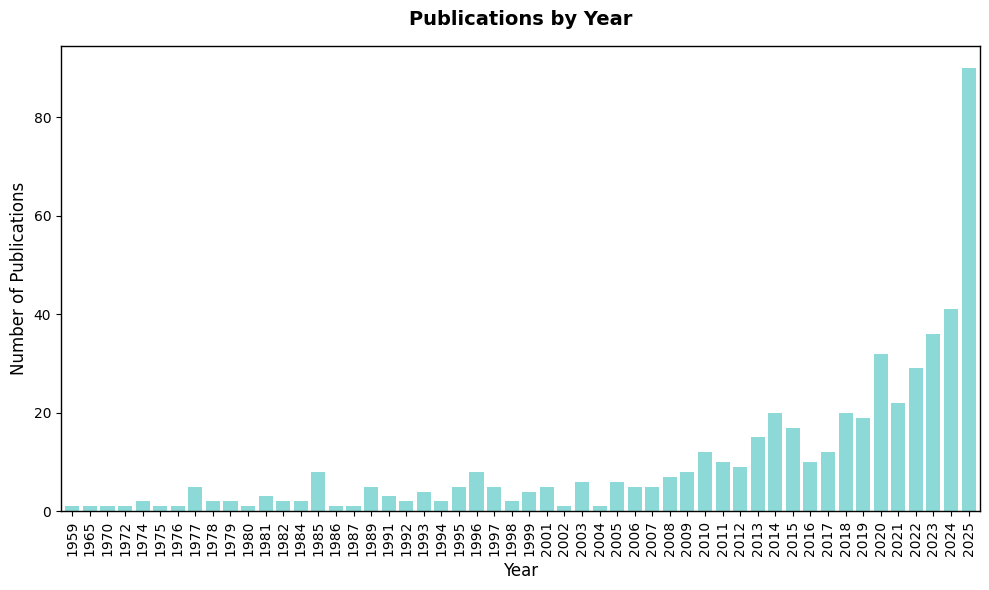

In [18]:
year_counts = selected_paper["year"].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
bars = year_counts.plot(kind="bar", color='#8dd9d8', width=0.8)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)
plt.title("Publications by Year", fontsize=14, pad=15, fontweight='bold')

# Ensure all borders are visible (complete box)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

# Optional: Add labels on bars
# ax.bar_label(bars.containers[0], padding=3)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Abstract Analysis

In [11]:
import string
from nltk.tokenize import word_tokenize
import nltk
from nltk.corpus import stopwords
import spacy

nlp = spacy.load("en_core_web_sm")

CUSTOM_REMOVE = {
    "abstract", "background", "methods", "results", "conclusion",
    "objective", "materials", "aims", "purpose", "study", "studies",
    "findings", "author", "limitations", "originality",
    "design", "methodology", "approach", "el"
}

def clean_text(text):
    text = text.lower()
    text = text.translate(text.maketrans('', '', string.punctuation))

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))

    filtered_words = [
        word for word in tokens
        if word not in stop_words
        and word not in CUSTOM_REMOVE
        and not any(char.isdigit() for char in word)  # 🚫 remove numbers
    ]

    text = " ".join(filtered_words)
    doc = nlp(text)

    lemmatized_tokens = [token.lemma_ for token in doc]


    return lemmatized_tokens


# def clean_text(text):
#     text = text.lower()
#     text = text.translate(text.maketrans('', '', string.punctuation))

#     tokens = word_tokenize(text)
#     stop_words = stopwords.words("english") 
#     filtered_words = [word for word in tokens if word.lower() not in stop_words]

#     text = " ".join(filtered_words)
#     doc = nlp(text)
#     lemmatized_tokens =  [token.lemma_ for token in doc]

#     return lemmatized_tokens

selected_paper['cleaned_abstract'] = selected_paper['abstract'].apply(clean_text)


/var/folders/xp/l7xvzzsx1h5bwwkb0446l2lc0000gn/T/ipykernel_73884/4177409688.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_paper['cleaned_abstract'] = selected_paper['abstract'].apply(clean_text)


In [12]:
bins = [1970, 1990, 2010, 2026]
labels = ['1970–1989', '1990–2009', '2010–2025']

# Create the new column
selected_paper['Year_Range'] = pd.cut(selected_paper['year'], bins=bins, labels=labels, right=False)


# Loop through unique labels, explicitly dropping NaN values
for label in selected_paper['Year_Range'].dropna().unique():
    # Use str(label) as a safeguard to ensure .replace() always works
    var_name = f"df_{str(label).replace('-', '_')}"
    
    # Create the dynamic global variable
    globals()[var_name] = selected_paper[selected_paper['Year_Range'] == label].copy()

/var/folders/xp/l7xvzzsx1h5bwwkb0446l2lc0000gn/T/ipykernel_73884/2656984523.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_paper['Year_Range'] = pd.cut(selected_paper['year'], bins=bins, labels=labels, right=False)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.util import ngrams
from nltk.probability import FreqDist
import warnings
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore') 

# --------------------------------------------------
# Helper function to plot on a single axis (from previous turn)
# --------------------------------------------------
def plot_ngrams_on_ax(dataframe, title_label, ax, n_value, top_n):
    """Plots top N n-grams from 'cleaned_abstract' column onto a specific axis."""
    if 'cleaned_abstract' not in dataframe.columns or dataframe['cleaned_abstract'].isnull().all():
        ax.set_title(f"No data for {title_label}")
        ax.axis('off') # Hide axis if no data
        return

    all_words = [item for sublist in dataframe["cleaned_abstract"].dropna() for item in sublist]

    if not all_words:
        ax.set_title(f"No words for {title_label}")
        ax.axis('off')
        return
        
    try:
        ngrams_list = [' '.join(gram) for gram in ngrams(all_words, n_value)]
        fdist = FreqDist(ngrams_list)
        most_common = fdist.most_common(top_n)
        
        if not most_common:
             ax.set_title(f"No n-grams for {title_label}")
             ax.axis('off')
             return

        ngrams_words, counts = zip(*most_common)

        # Plot directly onto the provided axis 'ax'
        ax.barh(ngrams_words, counts, color="#8dd9d8")
        ax.set_xlabel("Frequency")
        ax.set_ylabel(f"{n_value}-grams")
        ax.set_title(f"Abstracts from {title_label}")
        ax.invert_yaxis() # Put most frequent at the top
        
    except ValueError as e:
        ax.set_title(f"Error for {title_label}")
        print(f"Error processing n-grams for {title_label}: {e}")

# --------------------------------------------------
# Main function to generate all subplots
# --------------------------------------------------
# def plot_decade_ngram_frequencies(full_df, bins, labels, n_value=2, top_n=10):
#     """
#     Generates a 3x2 subplot grid showing top n-gram frequencies for different decades.

#     Args:
#         full_df (pd.DataFrame): The source DataFrame containing 'year' and 'cleaned_abstract' data.
#         bins (list): List of year boundaries for binning.
#         labels (list): Labels corresponding to the bins.
#         n_value (int): The size of the n-gram (1=unigram, 2=bigram, etc.).
#         top_n (int): The number of top results to plot for each decade.
#     """
#     # Ensure 'Year_Range' column exists for filtering
#     if 'Year_Range' not in full_df.columns:
#         full_df['Year_Range'] = pd.cut(full_df['year'], bins=bins, labels=labels, right=False)

#     # Setup the 3x2 subplot grid
#     fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
#     all_axes = axes.flatten()
#     unique_labels = full_df['Year_Range'].dropna().unique()

#     # Loop through labels and plot on the corresponding axis
#     for i, label in enumerate(labels):
#         if i >= len(all_axes):
#             break 

#         current_ax = all_axes[i]
#         current_df = full_df[full_df['Year_Range'] == label].copy()
        
#         # Call the helper function with parameters
#         plot_ngrams_on_ax(
#             current_df, 
#             title_label=str(label), 
#             ax=current_ax, 
#             n_value=n_value, 
#             top_n=top_n
#         )

#     # Final plot adjustments
#     plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
#     plt.suptitle(f"Top {top_n} {n_value}-gram Frequencies by Decade", fontsize=20, y=0.98)
#     plt.show()

import math
import pandas as pd
import matplotlib.pyplot as plt

def plot_decade_ngram_frequencies(full_df, bins, labels, n_value=2, top_n=10):
    """
    Generates a subplot grid (3 columns) showing top n-gram frequencies by time period.
    """
    df = full_df.copy()

    # Always (re)create Year_Range so bins/labels stay consistent
    df['Year_Range'] = pd.cut(
        df['year'],
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True
    )

    # ---- 3-column layout ----
    ncols = 3
    n_panels = len(labels)
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(18, 6 * nrows)
    )

    axes = axes.flatten()

    # # Plot each period
    # for i, label in enumerate(labels):
    #     current_ax = axes[i]
    #     current_df = df[df['Year_Range'] == label].copy()

    #     plot_ngrams_on_ax(
    #         current_df,
    #         title_label=str(label),
    #         ax=current_ax,
    #         n_value=n_value,
    #         top_n=top_n
    #     )

    for i, label in enumerate(labels):
        current_ax = axes[i]
        current_df = df[df['Year_Range'] == label].copy()

        plot_ngrams_on_ax(
            current_df,
            title_label=str(label),
            ax=current_ax,
            n_value=n_value,
            top_n=top_n
        )

        # Increase x and y axis tick font size
        current_ax.tick_params(axis='both', labelsize=14)

    # Hide unused axes
    for j in range(n_panels, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(
        f"Top {top_n} {n_value}-gram Frequencies by Period",
        fontsize=20,
        y=0.98
    )
    plt.show()


# --------------------------------------------------
# Example of how to call the function
# --------------------------------------------------

# You would define your full_df, bins, and labels here before calling:
# bins = [1970, 1980, 1990, 2000, 2010, 2020, 2030]
# labels = ['1970s-1980s', '1980s-1990s', '1990s-2000s', '2000s-2010s', '2010s-2020s', '2020s-2025']

bins = [1970, 1990, 2010, 2026]
labels = ['1970–1989', '1990–2009', '2010–2025']

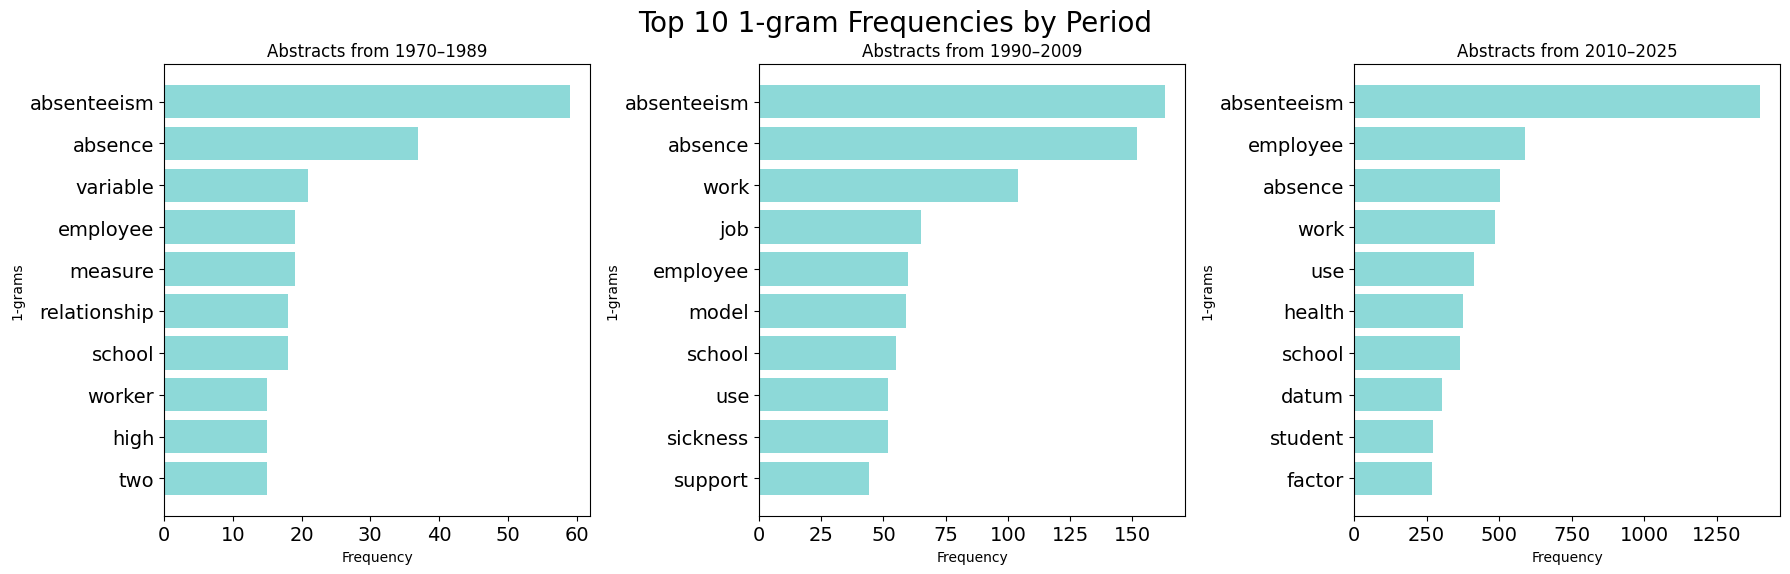

In [14]:
plot_decade_ngram_frequencies(selected_paper, bins, labels, n_value=1, top_n=10)

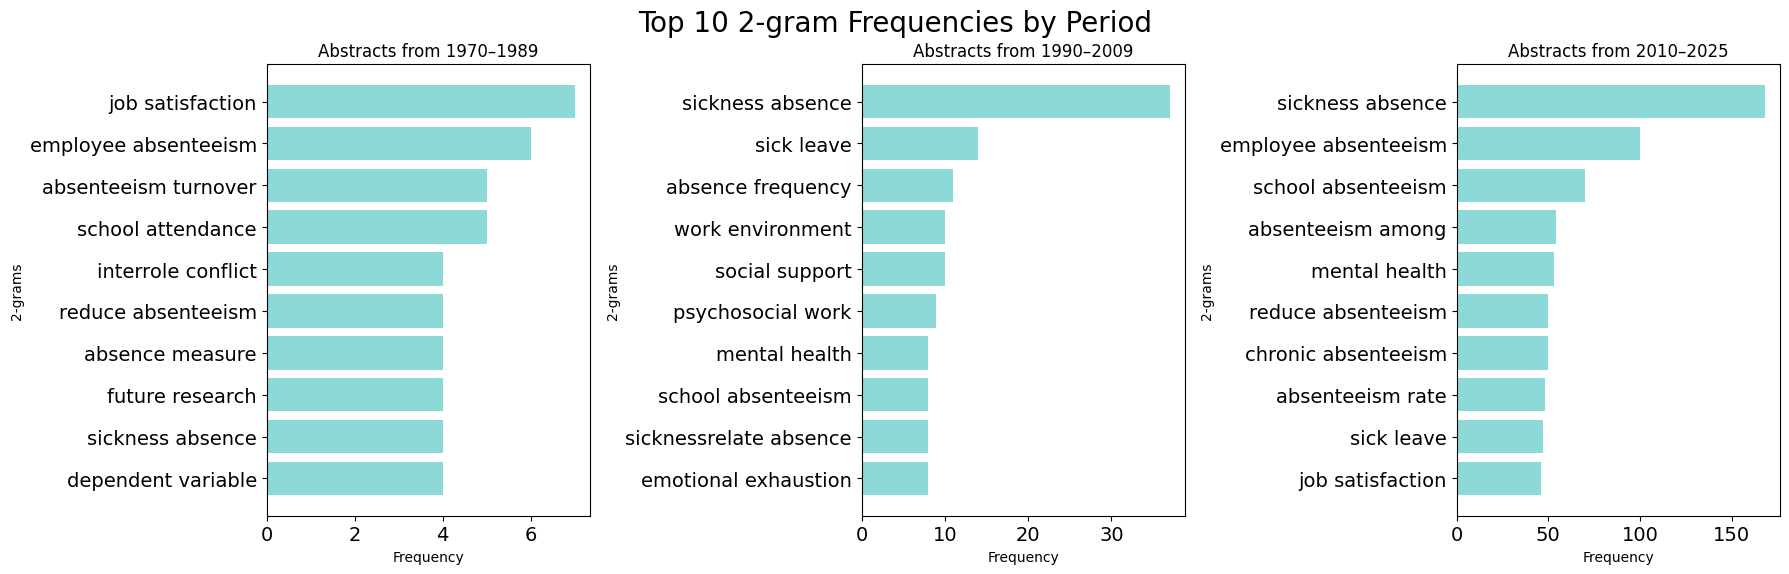

In [15]:
plot_decade_ngram_frequencies(selected_paper, bins, labels, n_value=2, top_n=10)

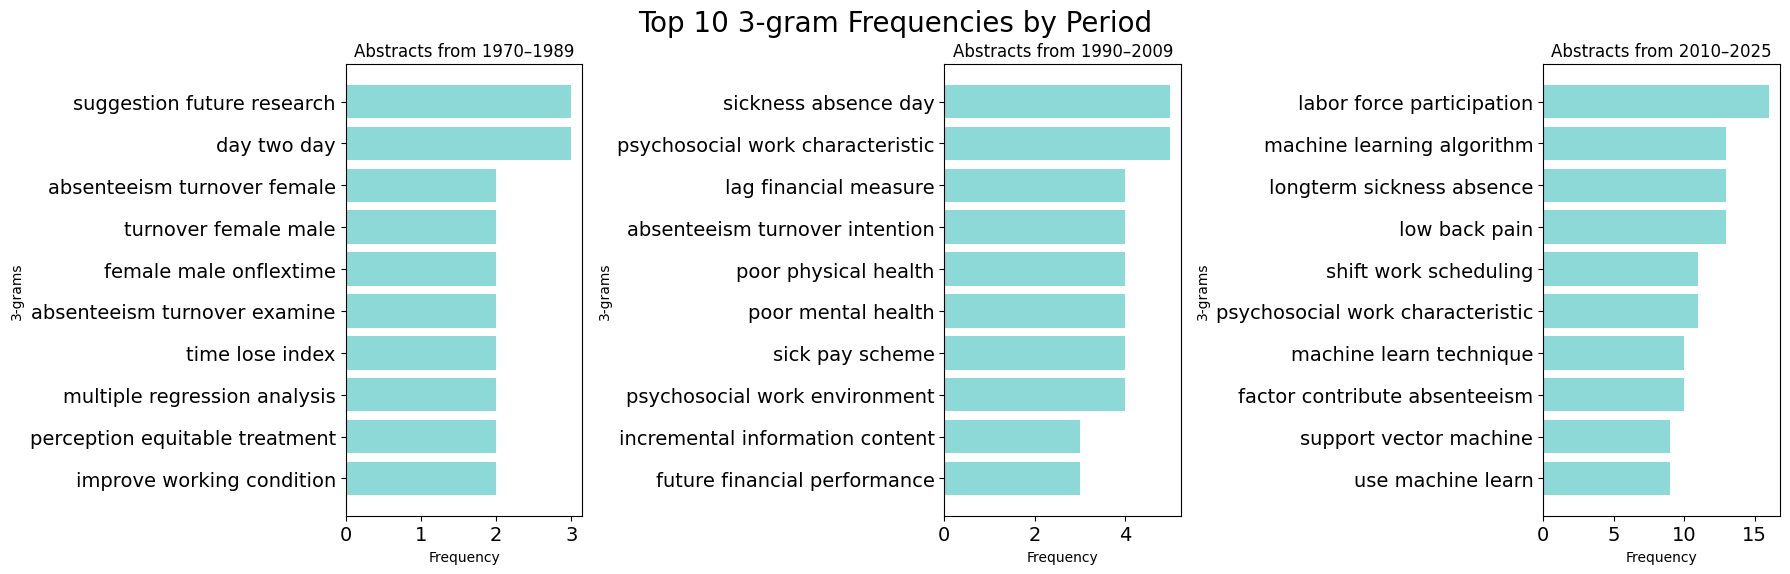

In [16]:
plot_decade_ngram_frequencies(selected_paper, bins, labels, n_value=3, top_n=10)